In [6]:
"""
01_data_exploration.ipynb

Goal: understand the CaBuAr dataset structure, visualize sample patches,
and compute basic statistics that will inform the data loading pipline.
"""

from pathlib import Path

import h5py
import hdf5plugin # noqa: F401 - required for BZip2 decompression of CaBuAr files
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "cabuar"
TRAIN_FILE = DATA_DIR / "raw" / "patched" / "512x512.hdf5"
TEST_FILE = DATA_DIR/ "raw" / "patched" / "chabud_test.h5"

print(f"Project root: {PROJECT_ROOT}")
print(f"Train file: {TRAIN_FILE}")
print(f"Train exists: {TRAIN_FILE.exists()}")
print(f"Test file: {TEST_FILE}")
print(f"Test exists: {TEST_FILE.exists()}")

Project root: c:\Users\chavo\ml-learning\sentinel2-burn-segmentation
Train file: c:\Users\chavo\ml-learning\sentinel2-burn-segmentation\data\raw\cabuar\raw\patched\512x512.hdf5
Train exists: True
Test file: c:\Users\chavo\ml-learning\sentinel2-burn-segmentation\data\raw\cabuar\raw\patched\chabud_test.h5
Test exists: True


In [7]:
def describe_sample(sample_group: h5py.Group, name: str) -> None:
    """Print info about one sample group's contents."""
    print(f"\nSample '{name}' contains {len(sample_group)} datasets:")
    for key in sample_group.keys():
        ds = sample_group[key]
        print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}")
        # Quick value range sample (read just a tiny slice to avoid loading the whole array)
        if ds.ndim >= 2:
            sample_vals = ds[0:5, 0:5] if ds.ndim == 2 else ds[0:5, 0:5, 0]
            print(f"    sample values: min={sample_vals.min()}, max={sample_vals.max()}")


def describe_hdf5(filepath: Path) -> None:
    print(f"\nInspecting: {filepath.name}")
    print(f"Size: {filepath.stat().st_size / 1024**2:.1f} MB")

    with h5py.File(filepath, "r") as f:
        top_keys = list(f.keys())
        print(f"\nTotal samples: {len(top_keys)}")
        print(f"Example sample names: {top_keys[:3]}")

        # Count unique fires (UUIDs before the _N suffix)
        unique_fires = {k.rsplit("_", 1)[0] for k in top_keys}
        print(f"Unique fire events (UUIDs): {len(unique_fires)}")
        print(f"Patches per fire (avg): {len(top_keys) / len(unique_fires):.1f}")

        # Drill into the first sample
        first_name = top_keys[0]
        first_sample = f[first_name]
        describe_sample(first_sample, first_name)


describe_hdf5(TRAIN_FILE)


Inspecting: 512x512.hdf5
Size: 5608.1 MB

Total samples: 534
Example sample names: ['012b8863-976c-44e1-a491-9adf19c1cbba_0', '0328d12a-4ad8-4504-8ac5-70089db10b4e_0', '0328d12a-4ad8-4504-8ac5-70089db10b4e_1']
Unique fire events (UUIDs): 298
Patches per fire (avg): 1.8

Sample '012b8863-976c-44e1-a491-9adf19c1cbba_0' contains 3 datasets:
  mask: shape=(512, 512, 1), dtype=uint16
    sample values: min=0, max=0
  post_fire: shape=(512, 512, 12), dtype=uint16
    sample values: min=1060, max=1133
  pre_fire: shape=(512, 512, 12), dtype=uint16
    sample values: min=161, max=239


In [8]:
def load_sample(filepath: Path, sample_name: str | None = None) -> dict:
    """Load one sample from the HDF5 file as numpy arrays.
    
    If sample_name is None, returns the first sample.
    """
    with h5py.File(filepath, "r") as f:
        if sample_name is None:
            sample_name = list(f.keys())[0]
        
        sample = f[sample_name]
        # [:] reads the dataset into a numpy array in memory
        # np.squeeze removes the trailing singleton dim from the mask
        return {
            "name": sample_name,
            "pre_fire": sample["pre_fire"][:],
            "post_fire": sample["post_fire"][:],
            "mask": np.squeeze(sample["mask"][:]),
        }


# Find a sample with a substantial burn area so the visualization is interesting.
# (The first sample's corner mask is all zeros, but the center might be too.)
def find_sample_with_burn(filepath: Path, min_burn_pixels: int = 5000) -> str:
    """Scan samples and return the name of the first one with enough burn pixels."""
    with h5py.File(filepath, "r") as f:
        for name in f.keys():
            # Reading just the mask is fast; reading post_fire would be slow
            mask = f[name]["mask"][:]
            if mask.sum() >= min_burn_pixels:
                burn_pct = 100 * mask.sum() / mask.size
                print(f"Selected '{name}': {int(mask.sum())} burn pixels ({burn_pct:.1f}%)")
                return name
    raise RuntimeError("No sample with enough burn area found")


sample_name = find_sample_with_burn(TRAIN_FILE, min_burn_pixels=20000)
sample = load_sample(TRAIN_FILE, sample_name)

print(f"\nLoaded sample: {sample['name']}")
print(f"  pre_fire:  shape={sample['pre_fire'].shape}, dtype={sample['pre_fire'].dtype}")
print(f"  post_fire: shape={sample['post_fire'].shape}, dtype={sample['post_fire'].dtype}")
print(f"  mask:      shape={sample['mask'].shape}, dtype={sample['mask'].dtype}")
print(f"  mask values: {np.unique(sample['mask'])}")
print(f"  mask burn fraction: {100 * sample['mask'].mean():.1f}%")

Selected '039885ad-e4f2-461e-9784-60508d0a7ab5_0': 58017 burn pixels (22.1%)

Loaded sample: 039885ad-e4f2-461e-9784-60508d0a7ab5_0
  pre_fire:  shape=(512, 512, 12), dtype=uint16
  post_fire: shape=(512, 512, 12), dtype=uint16
  mask:      shape=(512, 512), dtype=uint16
  mask values: [0 1]
  mask burn fraction: 22.1%


Saved figure to: c:\Users\chavo\ml-learning\sentinel2-burn-segmentation\docs\hero_sample.png


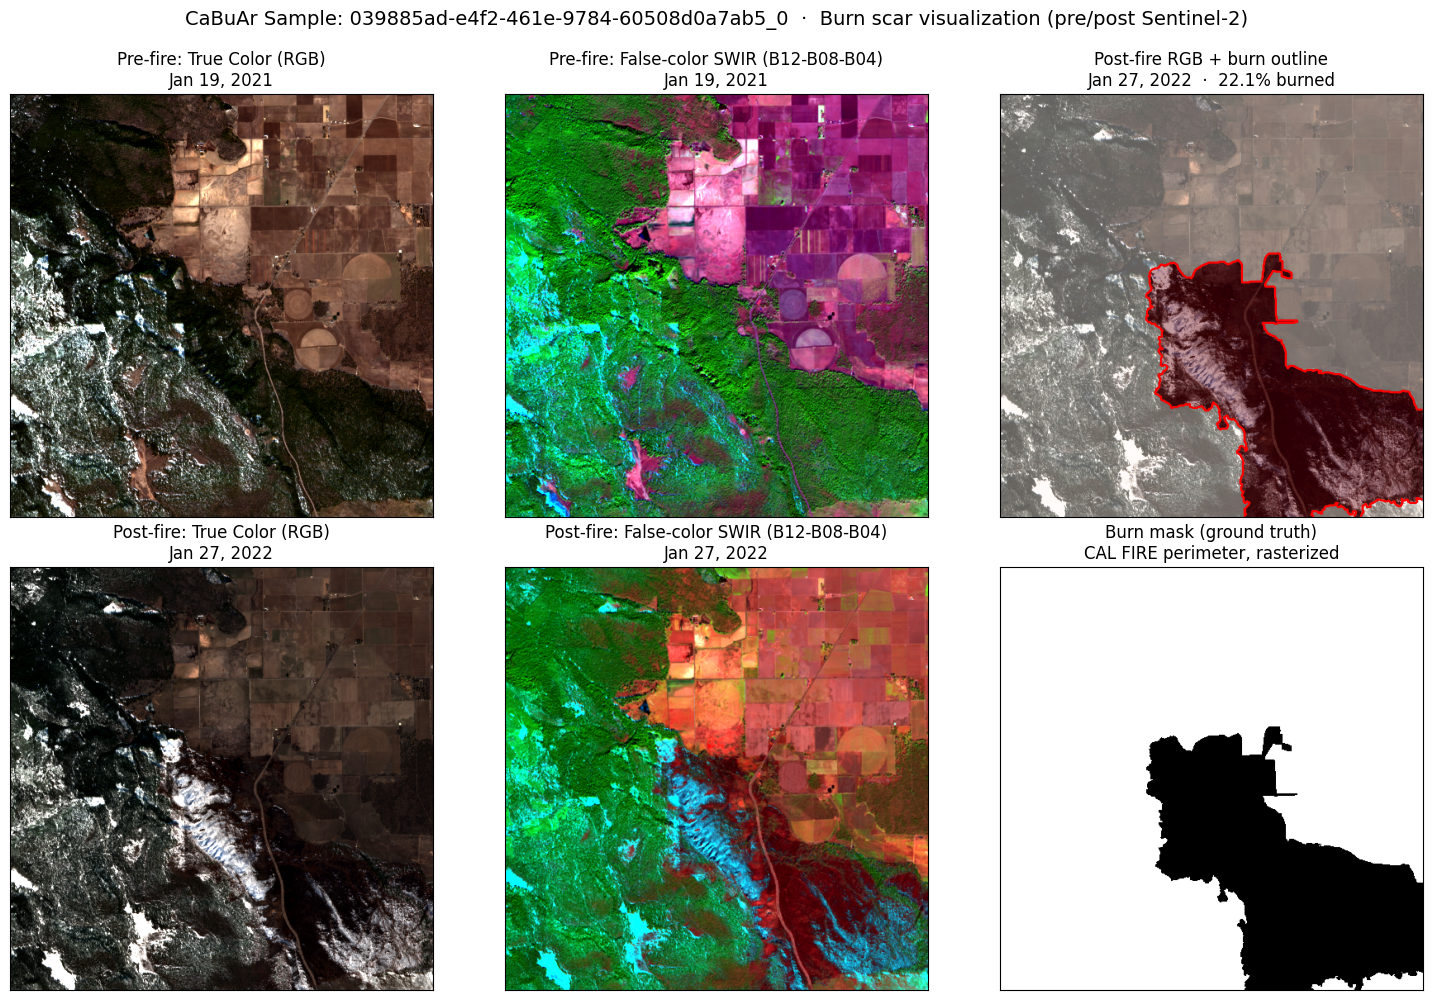

In [17]:
# --- Band index constants (Sentinel-2 standard order in CaBuAr) ---
# Use these by name in code rather than magic numbers.
B_BLUE   = 1   # B02
B_GREEN  = 2   # B03
B_RED    = 3   # B04
B_NIR    = 7   # B08
B_SWIR1  = 10  # B11
B_SWIR2  = 11  # B12


def stretch_for_display(img: np.ndarray, lo_pct: float = 2.0, hi_pct: float = 98.0) -> np.ndarray:
    """Percentile-clip and rescale an HxWx3 image to 0-1 for matplotlib display.

    Each channel is stretched independently so the visualization makes maximum
    use of the dynamic range. This is for display only - never used for training.
    """
    img = img.astype(np.float32)
    out = np.zeros_like(img)
    for c in range(img.shape[-1]):
        channel = img[..., c]
        lo = np.percentile(channel, lo_pct)
        hi = np.percentile(channel, hi_pct)
        if hi > lo:
            out[..., c] = np.clip((channel - lo) / (hi - lo), 0, 1)
    return out


def make_rgb(image_12band: np.ndarray) -> np.ndarray:
    """Extract true-color RGB (B04, B03, B02) and stretch for display."""
    rgb = image_12band[..., [B_RED, B_GREEN, B_BLUE]]
    return stretch_for_display(rgb)


def make_swir_composite(image_12band: np.ndarray) -> np.ndarray:
    """Extract false-color SWIR composite (B12, B08, B04).

    This composite is the remote-sensing standard for visualizing burn scars:
    - Healthy vegetation appears bright green (high NIR)
    - Fresh burn scars appear dark red/brown (high SWIR-2, low NIR)
    - Bare soil and clouds appear bright across all bands
    """
    swir = image_12band[..., [B_SWIR2, B_NIR, B_RED]]
    return stretch_for_display(swir)


# Build the four visualizations
pre_rgb     = make_rgb(sample["pre_fire"])
post_rgb    = make_rgb(sample["post_fire"])
pre_swir    = make_swir_composite(sample["pre_fire"])
post_swir   = make_swir_composite(sample["post_fire"])
mask        = sample["mask"]

# 2 rows x 3 columns: pre-fire row, post-fire row, mask column shared
fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor="white")

# --- Top row: pre-fire ---
axes[0, 0].imshow(pre_rgb)
axes[0, 0].set_title(f"Pre-fire: True Color (RGB)\n{pre_date}", fontsize=12)

axes[0, 1].imshow(pre_swir)
axes[0, 1].set_title(f"Pre-fire: False-color SWIR (B12-B08-B04)\n{pre_date}", fontsize=12)

axes[0, 2].imshow(post_rgb)  # paired with post_rgb to compare easily
axes[0, 2].imshow(mask, cmap="Reds", alpha=0.4)
axes[0, 2].set_title(f"Post-fire RGB + burn outline\n{post_date}  ·  {100*mask.mean():.1f}% burned", fontsize=12)

# --- Bottom row: post-fire ---
axes[1, 0].imshow(post_rgb)
axes[0, 2].contour(mask, levels=[0.5], colors="red", linewidths=1.5)
axes[1, 0].set_title(f"Post-fire: True Color (RGB)\n{post_date}", fontsize=12)

axes[1, 1].imshow(post_swir)
axes[1, 1].set_title(f"Post-fire: False-color SWIR (B12-B08-B04)\n{post_date}", fontsize=12)

axes[1, 2].imshow(mask, cmap="gray_r")
axes[1, 2].set_title("Burn mask (ground truth)\nCAL FIRE perimeter, rasterized", fontsize=12)

# Hide axis ticks on all panels for a clean look
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

# Overall title with the sample ID
fig.suptitle(
    f"CaBuAr Sample: {sample['name']}  ·  Burn scar visualization (pre/post Sentinel-2)",
    fontsize=14, y=0.995,
)
plt.tight_layout()
output_path = PROJECT_ROOT / "docs" / "hero_sample.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {output_path}")
plt.show()

In [11]:
import pandas as pd

METADATA_FILE = DATA_DIR / "metadata.parquet"
metadata = pd.read_parquet(METADATA_FILE)

print(f"Metadata shape: {metadata.shape}")
print(f"Columns: {list(metadata.columns)}")
print("\nFirst 3 rows:")
print(metadata.head(3))

Metadata shape: (65340, 8)
Columns: ['uuid', 'name', 'x', 'y', 'patch', 'crs', 'timestamp', 'post']

First 3 rows:
                                   uuid  \
0  79d08b9d-25b8-4ec5-988a-b7ece1f5c489   
1  79d08b9d-25b8-4ec5-988a-b7ece1f5c489   
2  79d08b9d-25b8-4ec5-988a-b7ece1f5c489   

                                                name  \
0  S2A_MSIL2A_20200614T181931_N0214_R127_T11SNT_2...   
1  S2A_MSIL2A_20200614T181931_N0214_R127_T11SNT_2...   
2  S2A_MSIL2A_20200614T181931_N0214_R127_T11SNT_2...   

                                                   x  \
0  [499990.0, 500010.0, 500030.0, 500050.0, 50007...   
1  [510230.0, 510250.0, 510270.0, 510290.0, 51031...   
2  [520470.0, 520490.0, 520510.0, 520530.0, 52055...   

                                                   y  patch    crs  \
0  [3800030.0, 3800010.0, 3799990.0, 3799970.0, 3...      0  32611   
1  [3800030.0, 3800010.0, 3799990.0, 3799970.0, 3...      1  32611   
2  [3800030.0, 3800010.0, 3799990.0, 3799970.0, 3...

In [13]:
# Sample name is like "039885ad-e4f2-461e-9784-60508d0a7ab5_0"
sample_uuid, patch_str = sample["name"].rsplit("_", 1)
patch_idx = int(patch_str)
print(f"Fire UUID:  {sample_uuid}")
print(f"Patch idx:  {patch_idx}")

# Find the matching row: same UUID, same patch, and post-fire (post=True)
match = metadata[
    (metadata["uuid"] == sample_uuid)
    & (metadata["patch"] == patch_idx)
    & (metadata["post"] == True)
]

print(f"\nMatching rows: {len(match)}")
print(match[["uuid", "name", "patch", "crs", "timestamp", "post"]])

Fire UUID:  039885ad-e4f2-461e-9784-60508d0a7ab5
Patch idx:  0

Matching rows: 1
                                       uuid  \
31702  039885ad-e4f2-461e-9784-60508d0a7ab5   

                                                    name  patch    crs  \
31702  S2A_MSIL2A_20220127T190641_N0400_R013_T10TEM_2...      0  32610   

                 timestamp  post  
31702  2022-01-27T19:06:41  True  


In [14]:
from pyproj import Transformer

row = match.iloc[0]
utm_crs = int(row["crs"])

# Grab the center pixel's UTM coords from the x/y arrays
x_arr = row["x"]
y_arr = row["y"]
x_center = float(x_arr[len(x_arr) // 2])
y_center = float(y_arr[len(y_arr) // 2])

# Convert UTM to WGS84 lat/lon
transformer = Transformer.from_crs(f"EPSG:{utm_crs}", "EPSG:4326", always_xy=True)
lon, lat = transformer.transform(x_center, y_center)

print(f"UTM (zone {utm_crs}): ({x_center:.0f} E, {y_center:.0f} N)")
print(f"WGS84:                ({lat:.4f}°N, {lon:.4f}°E)")
print(f"Google Maps URL:      https://www.google.com/maps?q={lat},{lon}")

UTM (zone 32610): (505110 E, 4694910 N)
WGS84:                (42.4065°N, -122.9379°E)
Google Maps URL:      https://www.google.com/maps?q=42.40647364736411,-122.93790138998301


In [15]:
# Look up BOTH the post-fire and pre-fire timestamps for this sample
post_match = metadata[
    (metadata["uuid"] == sample_uuid)
    & (metadata["patch"] == patch_idx)
    & (metadata["post"] == True)
]
pre_match = metadata[
    (metadata["uuid"] == sample_uuid)
    & (metadata["patch"] == patch_idx)
    & (metadata["post"] == False)
]

post_date = pd.to_datetime(post_match.iloc[0]["timestamp"]).strftime("%b %d, %Y")
pre_date = pd.to_datetime(pre_match.iloc[0]["timestamp"]).strftime("%b %d, %Y") if len(pre_match) > 0 else "unknown"

print(f"Pre-fire acquisition:  {pre_date}")
print(f"Post-fire acquisition: {post_date}")

Pre-fire acquisition:  Jan 19, 2021
Post-fire acquisition: Jan 27, 2022
